# 01 — Build Male CNS Network

**Dataset**: Janelia male CNS v0.9 (feather)

这个 notebook 演示如何：
1. 从 `/Users/lengyuner/Desktop/data/maleCNS` 读取 annotations + connectome weights
2. 用 `ConnectomeLoader.from_male_cns(...)` 过滤并构建 `(nodes_df, edges_df)`
3. 用 `ConnectomeNetwork.from_loader(...)` 构建 PyTorch 网络并做一次 forward

⚠️ 注意：`connectome-weights-...feather` 非常大（~150M edges）。请务必设置 `cell_types` / `super_classes` / `sides` 过滤，或者显式 `allow_large=True`。

**Date**: 2026-04-24


## 0. Setup


In [5]:
import os, sys, time, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import pyarrow.feather as feather

# Make sure we can import the local package when running from this notebook folder
sys.path.insert(0, os.path.abspath('../..'))

from neuro_framework.connectome import ConnectomeLoader, MaleCNSSkeletonIndex
from neuro_framework.models import ConnectomeNetwork, MorphologyGraph

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
print('torch:', torch.__version__)


torch: 2.2.0


## 1. 数据路径与文件检查


In [6]:
DATA_DIR = Path('/Users/lengyuner/Desktop/data/maleCNS')
assert DATA_DIR.exists(), f'Missing DATA_DIR: {DATA_DIR}'

expected = [
    'body-annotations-male-cns-v0.9-minconf-0.5.feather',
    'body-neurotransmitters-male-cns-v0.9.feather',
    'connectome-weights-male-cns-v0.9-minconf-0.5.feather',
]

print('DATA_DIR =', DATA_DIR)
for name in expected:
    p = DATA_DIR / name
    print(f'- {name}:', 'OK' if p.exists() else 'MISSING')

print('Skeleton folders:')
for p in [DATA_DIR/'skelton'/'skeletons-swc', DATA_DIR/'skelton'/'skeletons-swc-um']:
    print('-', p, 'exists=' + str(p.exists()))


DATA_DIR = /Users/lengyuner/Desktop/data/maleCNS
- body-annotations-male-cns-v0.9-minconf-0.5.feather: OK
- body-neurotransmitters-male-cns-v0.9.feather: OK
- connectome-weights-male-cns-v0.9-minconf-0.5.feather: OK
Skeleton folders:
- /Users/lengyuner/Desktop/data/maleCNS/skelton/skeletons-swc exists=True
- /Users/lengyuner/Desktop/data/maleCNS/skelton/skeletons-swc-um exists=True


## 2. 快速查看 annotations（只读 nodes，速度快）


In [7]:
anno_path = next(DATA_DIR.glob('body-annotations-male-cns-*.feather'))
nt_path = next(DATA_DIR.glob('body-neurotransmitters-male-cns-*.feather'))

anno = feather.read_table(anno_path, columns=['bodyId','type','superclass','rootSide','status']).to_pandas()
print('n_nodes =', len(anno))
print('n_types =', anno['type'].nunique())
print('n_superclasses =', anno['superclass'].nunique())

display(anno['type'].value_counts().head(20).rename('count').to_frame())
display(anno['superclass'].value_counts().head(20).rename('count').to_frame())

nt = feather.read_table(nt_path, columns=['body','consensus_nt','predicted_nt_confidence']).to_pandas()
print('n_nt_rows =', len(nt))
display(nt['consensus_nt'].value_counts().head(10).rename('count').to_frame())


n_nodes = 211743
n_types = 11732
n_superclasses = 26


,count
type,
R1-R6,3377
Tm3,2054
T3,1940
T2a,1872
L5,1787
C3,1779
L2,1779
T4c,1778
Tm1,1777


,count
superclass,
ol_intrinsic,89399
cb_intrinsic,32163
vnc_intrinsic,13160
visual_projection,9201
vnc_sensory,6374
ol_sensory,6098
cb_sensory,4870
ascending_neuron,1846
descending_neuron,1314


n_nt_rows = 1836293


,count
consensus_nt,
unclear,1672166
acetylcholine,100164
glutamate,29155
gaba,22227
histamine,8027
dopamine,4459
octopamine,51
serotonin,44


## 3. 选择一个子集（强烈建议）


下面给两个推荐起点：

- **超小 sanity 子集**：`CELL_TYPES = ['DNp01', 'DNp02', 'VCH']`（非常小，适合验证 pipeline）
- **中等规模子集**：`CELL_TYPES = ['LPLC2', 'LC16', 'LC13']`（~544 neurons，来自 `visual_projection`）

也可以用 `SUPER_CLASSES = ['descending_neuron']` 等方式。


In [8]:
# Pick ONE strategy:
CELL_TYPES = ['LPLC2', 'LC16', 'LC13']
SUPER_CLASSES = None
SIDES = None  # maleCNS uses 'R'/'L' in some rows; loader normalizes to 'right'/'left'

MIN_SYN_COUNT = 20  # increases sparsity; start high then lower
ALLOW_LARGE = False

print('CELL_TYPES    =', CELL_TYPES)
print('SUPER_CLASSES =', SUPER_CLASSES)
print('SIDES         =', SIDES)
print('MIN_SYN_COUNT =', MIN_SYN_COUNT)


CELL_TYPES    = ['LPLC2', 'LC16', 'LC13']
SUPER_CLASSES = None
SIDES         = None
MIN_SYN_COUNT = 20


## 4. 从 male CNS 构建 (nodes_df, edges_df)


In [9]:
t0 = time.time()
loader = ConnectomeLoader.from_male_cns(
    DATA_DIR,
    cell_types=CELL_TYPES,
    super_classes=SUPER_CLASSES,
    sides=SIDES,
    min_syn_count=MIN_SYN_COUNT,
    allow_large=ALLOW_LARGE,
)

nodes, edges = loader.load()
print(f'Loaded: nodes={len(nodes):,}, edges={len(edges):,}  (elapsed {time.time()-t0:.1f}s)')
display(nodes.head())
display(edges.head())
display(pd.Series(loader.summary()).to_frame('value'))


INFO [male_cns] Loading connectome from /Users/lengyuner/Desktop/data/maleCNS ...
INFO [male_cns] scanned 200/2318 batches (448.4 batches/s), kept 6 rows so far
INFO [male_cns] scanned 400/2318 batches (470.7 batches/s), kept 6 rows so far
INFO [male_cns] scanned 600/2318 batches (482.7 batches/s), kept 6 rows so far
INFO [male_cns] scanned 800/2318 batches (482.3 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1000/2318 batches (482.9 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1200/2318 batches (489.8 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1400/2318 batches (500.1 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1600/2318 batches (513.5 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1800/2318 batches (527.8 batches/s), kept 6 rows so far
INFO [male_cns] scanned 2000/2318 batches (544.1 batches/s), kept 6 rows so far
INFO [male_cns] scanned 2200/2318 batches (553.5 batches/s), kept 6 rows so far
INFO [male_cns] Loaded 544 neurons, 6 edge

Loaded: nodes=544, edges=6  (elapsed 4.6s)


,root_id,flywire_type,group,hemibrain_type,instance,itoleeHl,soma_side,statusLabel,super_class,supertype,cell_type,class,entryNerve,fruDsx,matchingNotes,side,assignedOlHex1,assignedOlHex2,mancBodyid,mancGroup,mancType,somaNeuromere,sub_class,trumanHl,dimorphism,synonyms,birthtime,mancSerial,mcnsSerial,exitNerve,serialMotif,receptorType,somaLocation,tosomaLocation,status,nt_score,nt_type,node_idx
0,11498,LPLC2,11498.0,LPLC2,LPLC2_L,VPNd1,L,Prelim Roughly traced,visual_projection,11498,LPLC2,None,None,None,None,unknown,NaN,NaN,NaN,NaN,None,None,unknown,None,None,None,None,NaN,NaN,None,None,None,"[68710, 20288, 32378]",None,Traced,0.971694,acetylcholine,0
1,12384,LPLC2,11498.0,LPLC2,LPLC2_L,VPNd1,L,Prelim Roughly traced,visual_projection,11498,LPLC2,None,None,None,None,unknown,NaN,NaN,NaN,NaN,None,None,unknown,None,None,None,None,NaN,NaN,None,None,None,"[70760, 18644, 32584]",None,Traced,0.963515,acetylcholine,1
2,13132,LPLC2,11498.0,LPLC2,LPLC2_L,VPNd1,L,Prelim Roughly traced,visual_projection,11498,LPLC2,None,None,None,None,unknown,NaN,NaN,NaN,NaN,None,None,unknown,None,None,None,None,NaN,NaN,None,None,None,"[69602, 19600, 31586]",None,Traced,0.961962,acetylcholine,2
3,13726,LPLC2,11498.0,LPLC2,LPLC2_L,VPNd1,L,Prelim Roughly traced,visual_projection,11498,LPLC2,None,None,None,None,unknown,NaN,NaN,NaN,NaN,None,None,unknown,None,None,None,None,NaN,NaN,None,None,None,"[69495, 18548, 31869]",None,Traced,0.939340,acetylcholine,3
4,13764,LPLC2,11498.0,LPLC2,LPLC2_L,VPNd1,L,Prelim Roughly traced,visual_projection,11498,LPLC2,None,None,None,None,unknown,NaN,NaN,NaN,NaN,None,None,unknown,None,None,None,None,NaN,NaN,None,None,None,"[69053, 19901, 33681]",None,Traced,0.959415,acetylcholine,4


,pre_root_id,post_root_id,syn_count,neuropil,pre_idx,post_idx
0,20471,23590,25,cns,41,69
1,13726,514670,23,cns,3,498
2,518731,515971,22,cns,514,501
3,520764,536444,21,cns,515,537
4,95241,514670,21,cns,470,498


,value
source,male_cns
n_neurons,544
n_edges,6
n_cell_types,3
n_super_classes,1
top_cell_types,"{'LPLC2': 185, 'LC16': 182, 'LC13': 177}"
mean_syn_count,22.166667
max_syn_count,25.0
nt_distribution,{'acetylcholine': 544}


## 5. 构建 PyTorch ConnectomeNetwork


In [10]:
net = ConnectomeNetwork.from_loader(loader, dynamics='voltage', synapse_model='simple')
print(net)
print('params =', net.n_parameters())


INFO [male_cns] Loading connectome from /Users/lengyuner/Desktop/data/maleCNS ...
INFO [male_cns] scanned 200/2318 batches (1071.6 batches/s), kept 6 rows so far
INFO [male_cns] scanned 400/2318 batches (1098.1 batches/s), kept 6 rows so far
INFO [male_cns] scanned 600/2318 batches (1092.0 batches/s), kept 6 rows so far
INFO [male_cns] scanned 800/2318 batches (1088.3 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1000/2318 batches (1086.5 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1200/2318 batches (1092.7 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1400/2318 batches (1104.1 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1600/2318 batches (1125.2 batches/s), kept 6 rows so far
INFO [male_cns] scanned 1800/2318 batches (1146.8 batches/s), kept 6 rows so far
INFO [male_cns] scanned 2000/2318 batches (1167.2 batches/s), kept 6 rows so far
INFO [male_cns] scanned 2200/2318 batches (1184.9 batches/s), kept 6 rows so far
INFO [male_cns] Loaded 544 neur

ConnectomeNetwork(n_nodes=544, n_edges=6, dynamics=VoltageModel, synapse=simple, trainable_params=1094)
params = 1094


## 6. Forward 仿真（随机输入 / 或只刺激前 K 个神经元）


y: (1, 200, 544) range= (-0.3606747090816498, 0.35985928773880005)


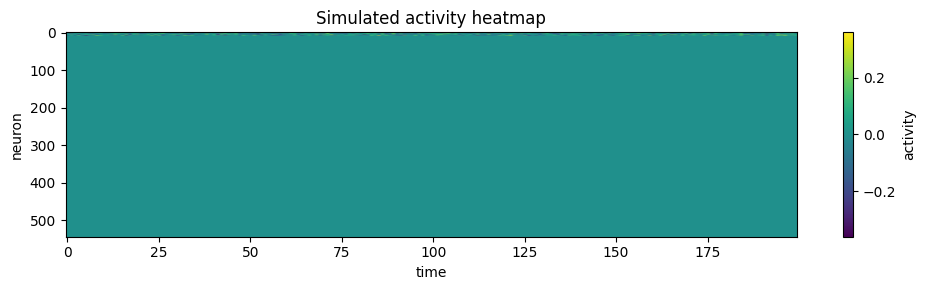

In [11]:
B, T = 1, 200
x = torch.zeros(B, T, net.n_nodes)
k = min(10, net.n_nodes)
x[:, :, :k] = torch.randn(B, T, k) * 0.1

with torch.no_grad():
    y = net(x, dt=1.0)

print('y:', tuple(y.shape), 'range=', (float(y.min()), float(y.max())))

plt.figure(figsize=(10, 3))
plt.imshow(y[0].T, aspect='auto', cmap='viridis')
plt.colorbar(label='activity')
plt.xlabel('time')
plt.ylabel('neuron')
plt.title('Simulated activity heatmap')
plt.tight_layout()
plt.show()


## 7. (Optional) 缓存当前子集到项目目录（下次不需要扫 150M edges）


In [12]:
# out_dir = Path('maleCNS_cache')
# out_dir.mkdir(exist_ok=True)
# nodes.to_parquet(out_dir / 'nodes.parquet', index=False)
# edges.to_parquet(out_dir / 'edges.parquet', index=False)
# print('Saved to', out_dir)


## 8. (Optional) 读取某个 neuron 的 SWC 形态并构建 MorphologyGraph


In [13]:
skel_index = MaleCNSSkeletonIndex.from_data_dir(DATA_DIR)
print('skeleton_dir =', skel_index.skeleton_dir)
print('scale_to_um  =', skel_index.scale_to_um)

example_body_id = int(nodes['root_id'].dropna().iloc[0])
swc_path = skel_index.require(example_body_id)
print('example_body_id =', example_body_id)
print('swc_path =', swc_path)

morph = MorphologyGraph.from_swc(str(swc_path), ncomp=2, scale=skel_index.scale_to_um)
print('morph n_comp =', morph.n_comp, 'n_branches =', morph.n_branches)
print('lengths (um): mean=', morph.lengths.mean(), 'median=', np.median(morph.lengths))


skeleton_dir = /Users/lengyuner/Desktop/data/maleCNS/skelton/skeletons-swc
scale_to_um  = 0.008
example_body_id = 11498
swc_path = /Users/lengyuner/Desktop/data/maleCNS/skelton/skeletons-swc/11498.swc
morph n_comp = 2 n_branches = 1
lengths (um): mean= 3.2747280730705275 median= 3.2747280730705275
